In [1]:
import mne
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import mne
import numpy as np
from scipy.stats import iqr
import warnings
import torch

from torch_geometric.data import Data


mne.set_log_level('ERROR')   # silence MNE

warnings.filterwarnings("ignore")  # silence warnings

In [2]:
latest_channel_list = [
    # Left sensorimotor area channels
    'E29', 'E30', 'E35', 'E36', 'E41', 'E42',
    # Right sensorimotor area channels
    'E103', 'E104', 'E109', 'E110', 'E115', 'E116',
    # Mid-parietal & bilateral parietal
    'E62', 'E67', 'E72', 'E77'
 ]

new_latest = ['E24', 'E124', 'E36', 'E104', 'E47','E52', ' E60', 'E67', 'E67', 'E72', 'E77', 'E85', 'E92', 'E98', 'E62','E70', 'E75', 'E83','E58','E96','E90','E65','E69','E74','E82','E89'
              ]

bad_channels = ['E17', 'E38', 'E94', 'E113', 'E119', 'E121', 'E125', 'E128', 'E73', 'E81', 'E88', 'E43', 'E44', 'E120', 'E114','E127', 'E126',
                 'E68', 'E23', 'E3','E49','E48', "E8", "E25",
     "E56", "E63", "E99", "E107"]


                 
#bad_channels = ['E48', 'E119', 'E49', 'E113', 'E94', 'E68', 'E23', 'E3', 'E126', 'E127']



#label_dict = {'OBBA': 0, 'OBBY': 1, 'OBDO': 2, 'OBMO': 3, 'OBSI':4}
label_dict = {'OBBA': 0,'OBDO': 1,'OBSI':2 } # banana, dog, sitar
directions = ['OBBA', 'OBDO', 'OBSI']

#directions = ['OBBA', 'OBBY', 'OBDO', 'OBDO','OBSI']  # Left, Right, Up, Down

In [3]:
# # Your target list (cleaned of spaces and duplicates)
# wanted = new_latest

# # Generate every possible channel from E1 to E128
# all_128 = [f'E{i}' for i in range(1, 129)]

# # Create the discard list: everything that is NOT in your wanted list
# discard_list = [ch for ch in all_128 if ch not in wanted]

# print(f"Total channels to discard: {len(discard_list)}")

In [4]:
channel_tuple = (new_latest, bad_channels)

In [ ]:

class preprocessing_pipeline:
    def __init__(self, filename, *channel_tuple, 
                 l_freq=8.0, h_freq=24.0, notch_freq=50.0, fs=500.0, time_window=0.5,
                 apply_ica=False, remove_muscle=True,
                 eog_vertical_chs=('E14', 'E21'), eog_horizontal_chs=('E1', 'E32')):
        
        self.filename = filename
        self.l_freq = l_freq
        self.h_freq = h_freq
        self.notch_freq = notch_freq
        self.time_window = time_window
        self.fs = fs
        self.active_channels = channel_tuple[0]
        self.bad_channels = channel_tuple[1]
        self.apply_ica = apply_ica
        self.remove_muscle = remove_muscle
        self.eog_vertical_chs = list(eog_vertical_chs)
        self.eog_horizontal_chs = list(eog_horizontal_chs)
        self.ica = None  # Store for inspection later

        self.raw = self.file_process()
        self.annotations = self.raw.annotations

    def file_process(self):
        raw = mne.io.read_raw_egi(self.filename, preload=True)
        
        if 'VREF' in raw.ch_names:
            raw.drop_channels(['VREF'])


        
        raw.pick('eeg')

        if self.bad_channels:
            raw.drop_channels([ch for ch in self.bad_channels if ch in raw.ch_names])

  

        # Filter BEFORE ICA (ICA needs broadband signal to detect artifacts)
        # Use 1Hz high-pass for ICA fitting even if analysis band is higher
        raw.notch_filter(freqs=self.notch_freq, picks='eeg', verbose=False, pad='edge')
        raw.filter(l_freq=1.0, h_freq=self.h_freq, picks='eeg', verbose=False, pad='edge')

        if self.apply_ica:
            raw = self._run_ica(raw)

        # Apply analysis band-pass AFTER ICA (if l_freq > 1.0)
        if self.l_freq > 1.0:
            raw.filter(l_freq=self.l_freq, h_freq=None, picks='eeg', verbose=False, pad='edge')

        # Average reference AFTER ICA
        raw.set_eeg_reference('average', projection=False)

        return raw

    def _run_ica(self, raw):
        """
        Adds EOG proxies, fits ICA, removes artifact components, 
        then strips proxy channels. Returns cleaned raw (EEG only).
        """
        # --- 1. Add EOG proxy channels temporarily ---
        eog_proxies_added = []

        vert_chs = [ch for ch in self.eog_vertical_chs if ch in raw.ch_names]
        if vert_chs:
            proxy = raw.copy().pick_channels(vert_chs).get_data().mean(axis=0)
            info = mne.create_info(['EOG_vertical'], raw.info['sfreq'], ch_types=['eog'])
            raw.add_channels([mne.io.RawArray(proxy[np.newaxis, :], info)], force_update_info=True)
            eog_proxies_added.append('EOG_vertical')

        horiz_chs = [ch for ch in self.eog_horizontal_chs if ch in raw.ch_names]
        if horiz_chs:
            proxy = raw.copy().pick_channels(horiz_chs).get_data().mean(axis=0)
            info = mne.create_info(['EOG_horizontal'], raw.info['sfreq'], ch_types=['eog'])
            raw.add_channels([mne.io.RawArray(proxy[np.newaxis, :], info)], force_update_info=True)
            eog_proxies_added.append('EOG_horizontal')

        # --- 2. Fit ICA on EEG channels only (not proxies) ---
        eeg_only = raw.copy().pick_types(eeg=True)
        rank = mne.compute_rank(eeg_only, tol=1e-6, tol_kind='relative')
        n_components = min(25, rank['eeg'])

        print(f"\n🔧 Fitting ICA with {n_components} components on {len(eeg_only.ch_names)} EEG channels...")
        ica = mne.preprocessing.ICA(
            n_components=n_components, 
            random_state=42,
            method='fastica', 
            max_iter=500
        )
        ica.fit(eeg_only)

        # --- 3. Detect bad components ---
        bad_components = []

        if 'EOG_vertical' in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name='EOG_vertical', threshold=2.5)
            print(f"  Vertical EOG (blinks): {idx}")
            bad_components.extend(idx)

        if 'EOG_horizontal' in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name='EOG_horizontal', threshold=2.5)
            print(f"  Horizontal EOG (saccades): {idx}")
            bad_components.extend(idx)

        if self.remove_muscle:
            try:
                idx, _ = ica.find_bads_muscle(raw, threshold=0.2)
                print(f"  Muscle artifacts: {idx}")
                bad_components.extend(idx)
            except Exception as e:
                print(f"  Muscle detection skipped: {e}")

        ica.exclude = sorted(set(bad_components))
        print(f"\n  Excluding {len(ica.exclude)}/{n_components} components: {ica.exclude}")
        self.ica = ica  # Save for later inspection

        # --- 4. Apply ICA to EEG-only copy, then re-attach annotations ---
        # Apply only to EEG channels (proxy channels are NOT passed to apply)
        raw_eeg_clean = ica.apply(eeg_only)  # operates on the eeg-only copy
        
        # Restore annotations (crop/copy loses them)
        raw_eeg_clean.set_annotations(raw.annotations)

        print(f"  ✅ ICA done. Final channel count: {len(raw_eeg_clean.ch_names)}")
        return raw_eeg_clean  # Pure EEG, proxies never re-added

    def baseline_stats(self):
        """Extract baseline statistics."""

        try:
            tmin = [ann['onset'] for ann in self.annotations if ann['description'] == 'BLCS'][0]
            tmax = [ann['onset'] for ann in self.annotations if ann['description'] == 'BLCE'][0]

            if not tmin or not tmax:
                print("inner if")
                tmin = [ann['onset'] for ann in self.annotations if ann['description'] == 'BSST'][0]
                tmax = [ann['onset'] for ann in self.annotations if ann['description'] == 'BSEN'][0]
            
            baseline_raw = self.raw.copy().crop(tmin = tmin, tmax = tmax)
            baseline_data = baseline_raw.get_data(picks = 'eeg')

            median = np.median(baseline_data, axis=1, keepdims=True)
            scale = iqr(baseline_data, axis=1, keepdims=True)

            scale = np.where(scale == 0, 1, scale)

            return median, scale

        except Exception as e:
            print(f"No baseline beta:{e}")
            return 0, 1
    # def baseline_stats(self):
    #     """Extract baseline statistics."""

    #     try:
    #         # tmin = [ann['onset'] for ann in self.annotations if ann['description'] == 'BLCS' or 'BSST']
    #         # tmax = [ann['onset'] for ann in self.annotations if ann['description'] == 'BLCE' or 'BSEN']

    #         tmin= ann['onset'] for ann in self.annotations if ann['description'] in ['BLCS', 'BSST']
    #         tmax = ann['onset'] for ann in self.annotations if ann['description'] in ['BLCE', 'BSEN']
    #         # if not tmin_list or not tmax_list:
    #         #     raise ValueError("No matching baseline markers found.")
    #         # tmin = float(tmin_list)
    #         # tmax = float(tmax_list)

           
    #         baseline_raw = self.raw.copy().crop(tmin = tmin, tmax = tmax)
    #         baseline_data = baseline_raw.get_data(picks = 'eeg')

    #         median = np.median(baseline_data, axis=1, keepdims=True)
    #         scale = iqr(baseline_data, axis=1, keepdims=True)

    #         scale = np.where(scale == 0, 1, scale)

    #         return median, scale

    #     except Exception as e:
    #         print(f"No baseline beta:{e}")
    #         return 0, 1

    def extracting_data(self, start_offset=0.3, end_offset=0.1, overlap_factor=0.8, normalize = True):
        base_mean, base_std = self.baseline_stats()
        
        #classes = ['BA', 'BY', 'DO', 'MO', 'SI']
        classes = ['BA', 'DO', 'SI']
        # Changed from flat list to a dictionary grouped by class
        trial_groups = {cls: [] for cls in classes} 

        for cls in classes:
            starts = [ann['onset'] for ann in self.annotations if ann['description'] == f'OS{cls}']
            ends   = [ann['onset'] for ann in self.annotations if ann['description'] == f'OE{cls}']

            for start, end in zip(starts, ends):
                segment = self.raw.copy().crop(tmin=start+start_offset, tmax=end+end_offset)
                data = segment.get_data(picks='eeg').astype(np.float32)

                if normalize is not None:
                    data = (data - base_mean)/base_std

                window_samples = int(self.time_window * self.fs)
                step_samples = int(window_samples * (1-overlap_factor))
                
                total_samples = data.shape[1]
                this_trial_windows = []
                
                for start_pt in range(0, total_samples - window_samples + 1, step_samples):
                    chunk = data[:, start_pt:start_pt + window_samples]
                    this_trial_windows.append(chunk)

                if this_trial_windows:
                    # Store as a tuple: (Array of Windows, Label)
                    X_windows = np.stack(this_trial_windows, axis=0)
                    y_windows = np.full(X_windows.shape[0], label_dict[f'OB{cls}'])
                    trial_groups[cls].append((X_windows, y_windows))

        return trial_groups



In [8]:
import os

# Point this to the parent "Data" directory
base_dir = "/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/Data"
#base_dir = "/home/kavinfidel/projects/VM_EEG/Data"
subject_dirs = {}

# 1. Get all items in the Data folder
# 2. Filter for directories that start with 'S'
sub_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f)) and f.startswith('S')]

for folder in sub_folders:
    folder_path = os.path.join(base_dir, folder)
    files = []
    
    # List all .mff files within each subject's folder
    for file_name in os.listdir(folder_path):
        if not file_name.startswith('.') and file_name.endswith('.mff'):
            files.append(file_name)
    
    # Using the actual folder name (e.g., 'S1', 'S113') as the key
    subject_dirs[folder] = files

# Verification
print(f"Found {len(subject_dirs)} subjects.")
print("Subjects identified:", list(subject_dirs.keys()))

Found 15 subjects.
Subjects identified: ['S116', 'S118', 'S5', 'S2', 'S119', 'S117', 'S3', 'S4', 'S2_', 'S1_', 'S1', 'S6', 'S115', 'S113', 'S114']


In [9]:
total_data = {}
test_data = {}


for subject, files in subject_dirs.items(): # subject is id, files are the all the files associated with a subject
    print(f"Processing {subject}")
    
    total_data[f"{subject}"] = {} #?
    test_data[f"{subject}"] = {}
    signals = [] #?
    labels = []#?
    signals_test = []
    labels_test = []
    k = 0
    for file_name in files:
        k +=1
        file_path = os.path.join(base_dir,subject, file_name) # grabbing file path, the mff file?
        
        if not file_name.endswith('.mff'):
            print(f"Skipping non-raw file: {file_name}")
            continue
        
        required_parts = ["signal1.bin", "info1.xml"]
        missing_parts = [p for p in required_parts if not os.path.exists(os.path.join(file_path, p))] # wha tis happenign here?
        if missing_parts:
            print(f"Skipping {file_name} due to parts being missing")
            continue
        
        print(f"File is intact: {file_name}\n Beginning extraction...")
        

        try:
            processor = preprocessing_pipeline(file_path, *channel_tuple)
            # trial_data is now a dict: {'BA': [(win, lab), (win, lab), (win, lab)], ...}
            trial_data = processor.extracting_data()

            if k == 2:
                print(f"Splitting Block {k} into Training and Test...")
                for cls, trials in trial_data.items():
                    # 1. Take the LAST trial (image event) for Testing
                    test_trial_x, test_trial_y = trials.pop() 
                    signals_test.append(test_trial_x)
                    labels_test.append(test_trial_y)
                    
                    # 2. Put the REMAINING trials from this block into Training
                    for x, y in trials:
                        signals.append(x)
                        labels.append(y)
            else:
                # For Block 1 or 3, just put everything into Training
                for cls, trials in trial_data.items():
                    for x, y in trials:
                        signals.append(x)
                        labels.append(y)

        except Exception as e:
            print(f"Error processing {file_name}: {e}")
            continue

    
    total_data[f"{subject}"]['data'] = np.concatenate(signals, axis=0)
    total_data[f"{subject}"]['labels'] = np.concatenate(labels, axis=0)   
    
    test_data[f"{subject}"]['data'] = np.concatenate(signals_test, axis=0)
    test_data[f"{subject}"]['labels'] = np.concatenate(labels_test, axis=0)  

    

Processing S116
File is intact: VI_S6_S1_B3__20251116_110436.mff
 Beginning extraction...
File is intact: VI_SX_S2_B1_1__20260315_022327.mff
 Beginning extraction...
Splitting Block 2 into Training and Test...
File is intact: VI_S6_S1_B1__20251116_104819.mff
 Beginning extraction...
File is intact: VI_SX_S2_B2_2__20260315_023302.mff
 Beginning extraction...
File is intact: VI_SX_S2_B3_3__20260315_024046.mff
 Beginning extraction...
File is intact: VI_S6_S1_B2__20251116_105637.mff
 Beginning extraction...
Processing S118
File is intact: VI_S8_S1_B1__20251119_052228.mff
 Beginning extraction...
File is intact: VI_S8_S1_B2__20251119_053014.mff
 Beginning extraction...
Splitting Block 2 into Training and Test...
File is intact: VI_S8_S1_B3__20251119_053757.mff
 Beginning extraction...
Processing S5
File is intact: S5_S1_B3_1654_161025_20251016_045503.mff
 Beginning extraction...
No baseline beta:list index out of range
File is intact: S5_S1_B1_1640_161025_20251016_044052.mff
 Beginning ext

In [10]:
for subject in total_data.keys():
    data = total_data[subject]['data']
    labels = total_data[subject]['labels']
    
    print(f"--- Verification for {subject} ---")
    print(f"Data Shape: {data.shape}") 
    # Expected: (Total_Windows, Channels, Samples_per_Window)
    # Example: (1500, 128, 50) 
    
    print(f"Labels Shape: {labels.shape}")
    print(f"Unique Labels: {np.unique(labels)}")
    
    # Check if classes are balanced (should be roughly equal)
    unique, counts = np.unique(labels, return_counts=True)
    print("Samples per class:", dict(zip(unique, counts)))
    print("-" * 30)

--- Verification for S116 ---
Data Shape: (1786, 100, 250)
Labels Shape: (1786,)
Unique Labels: [0 1 2]
Samples per class: {0: 595, 1: 596, 2: 595}
------------------------------
--- Verification for S118 ---
Data Shape: (840, 100, 250)
Labels Shape: (840,)
Unique Labels: [0 1 2]
Samples per class: {0: 280, 1: 280, 2: 280}
------------------------------
--- Verification for S5 ---
Data Shape: (840, 100, 250)
Labels Shape: (840,)
Unique Labels: [0 1 2]
Samples per class: {0: 280, 1: 280, 2: 280}
------------------------------
--- Verification for S2 ---
Data Shape: (840, 100, 250)
Labels Shape: (840,)
Unique Labels: [0 1 2]
Samples per class: {0: 280, 1: 280, 2: 280}
------------------------------
--- Verification for S119 ---
Data Shape: (840, 100, 250)
Labels Shape: (840,)
Unique Labels: [0 1 2]
Samples per class: {0: 280, 1: 280, 2: 280}
------------------------------
--- Verification for S117 ---
Data Shape: (840, 100, 250)
Labels Shape: (840,)
Unique Labels: [0 1 2]
Samples per cla

In [11]:
for subject in test_data.keys():
    data = test_data[subject]['data']
    labels = test_data[subject]['labels']
    
    print(f"--- Verification for {subject} ---")
    print(f"Data Shape: {data.shape}") 
    # Expected: (Total_Windows, Channels, Samples_per_Window)
    # Example: (1500, 128, 50) 
    
    print(f"Labels Shape: {labels.shape}")
    print(f"Unique Labels: {np.unique(labels)}")
    
    # Check if classes are balanced (should be roughly equal)
    unique, counts = np.unique(labels, return_counts=True)
    print("Samples per class:", dict(zip(unique, counts)))
    print("-" * 30)

--- Verification for S116 ---
Data Shape: (105, 100, 250)
Labels Shape: (105,)
Unique Labels: [0 1 2]
Samples per class: {0: 35, 1: 35, 2: 35}
------------------------------
--- Verification for S118 ---
Data Shape: (105, 100, 250)
Labels Shape: (105,)
Unique Labels: [0 1 2]
Samples per class: {0: 35, 1: 35, 2: 35}
------------------------------
--- Verification for S5 ---
Data Shape: (105, 100, 250)
Labels Shape: (105,)
Unique Labels: [0 1 2]
Samples per class: {0: 35, 1: 35, 2: 35}
------------------------------
--- Verification for S2 ---
Data Shape: (105, 100, 250)
Labels Shape: (105,)
Unique Labels: [0 1 2]
Samples per class: {0: 35, 1: 35, 2: 35}
------------------------------
--- Verification for S119 ---
Data Shape: (105, 100, 250)
Labels Shape: (105,)
Unique Labels: [0 1 2]
Samples per class: {0: 35, 1: 35, 2: 35}
------------------------------
--- Verification for S117 ---
Data Shape: (105, 100, 250)
Labels Shape: (105,)
Unique Labels: [0 1 2]
Samples per class: {0: 35, 1: 35

In [ ]:
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

In [ ]:
def riemannian_model_build(X_train,y_train,X_test, clf_type):
    cov_est = Covariances(estimator='oas')
    ts = TangentSpace(metric='riemann')
    scaler = StandardScaler()
    
    # step 01
    cov_train = cov_est.fit_transform(X_train)
    cov_test = cov_est.transform(X_test)
    
    # Step 02
    X_train_ts = ts.fit_transform(cov_train)
    X_test_ts = ts.transform(cov_test)
    
    # Step 03
    X_train_scaled = scaler.fit_transform(X_train_ts)
    X_test_scaled = scaler.transform(X_test_ts)
    
    if clf_type == 'logreg':
        clf = LogisticRegression(
            penalty='l2',
            solver='lbfgs',
            class_weight='balanced',
            max_iter=1000
        )
    
    elif clf_type == 'svm':
        clf =   SVC(
            kernel='linear',
            class_weight='balanced',
            C=1.0
        )
    elif clf_type == 'xgboost':
        # Ensure y_train is 0-indexed for XGBoost
        clf = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3)
        
    elif clf_type == 'mlp':
        clf = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, early_stopping=True)
    else:
        raise ValueError('No classifier model supported')
    
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    
    return y_pred        

In [12]:


def convert_to_graph_list(X_data, y_labels, threshold=0.3):
    """
    Bridges the gap: Numpy (Trials, Chs, Time) -> List of PyG Data objects
    """
    graph_list = []
    
    # Use OAS estimator for stable covariance with 118 channels
    cov_est = Covariances(estimator='oas')
    covariances = cov_est.fit_transform(X_data) # Shape: (Trials, 118, 118)

    for i in range(len(covariances)):
        # x: Use the covariance rows as node features (118 nodes, 118 features each)
        # This captures how each node relates to every other node geometrically.
        x = torch.tensor(covariances[i], dtype=torch.float32)
        
        # edge_index: Define connectivity based on covariance strength
        adj = np.abs(covariances[i])
        rows, cols = np.where(adj > threshold)
        
        # Remove self-loops
        mask = rows != cols
        edge_index = torch.tensor(np.stack([rows[mask], cols[mask]], axis=0), dtype=torch.long)
        
        # edge_attr: The actual covariance value as weight
        edge_attr = torch.tensor(adj[rows[mask], cols[mask]], dtype=torch.float32).unsqueeze(1)
        
        y = torch.tensor([y_labels[i]], dtype=torch.long)
        
        graph_list.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y))
        
    return graph_list

In [13]:
from models.RiemannianGAT import RiemannianGAT
from torch_geometric.loader import DataLoader

In [14]:


def train_riemannian_gnn(train_dict, test_dict, subject):
    # 1. Access the data from your existing dictionary
    X_train_raw = train_dict[subject]['data']   # (Trials, 118, 500)
    y_train_raw = train_dict[subject]['labels'] # (Trials,)
    
    X_test_raw = test_dict[subject]['data']
    y_test_raw = test_dict[subject]['labels']

    # 2. Bridge to PyG
    train_graphs = convert_to_graph_list(X_train_raw, y_train_raw)
    test_graphs = convert_to_graph_list(X_test_raw, y_test_raw)

    train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_graphs, batch_size=16, shuffle=False)

    # 3. Initialize Model
    # in_channels = 118 (because our feature x is the covariance row)
    model = RiemannianGAT(in_channels=100, hidden_channels=64, out_channels=3)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()
    total = 150

    # 4. Standard Training Loop
    model.train()
    for epoch in range(total):
        print(f"Epoch {epoch}/{total}")
        for batch in train_loader:
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            
    return model, test_loader

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
def train_riemannian_gnn(train_dict, test_dict, subject, epochs=500, batch_size=16):
    # Setup Device
    device = torch.device("cpu")
    print(f"--- Training Subject: {subject} on {device} ---")

    # 1. Data Prep & Validation Split
    # Since you have small data, we split the train_dict further to get a validation set
    raw_data = train_dict[subject]['data']
    raw_labels = train_dict[subject]['labels']
    
    # Stratified split ensures class balance in tiny datasets
    X_train, X_val, y_train, y_val = train_test_split(
        raw_data, raw_labels, test_size=0.2, stratify=raw_labels, random_state=42
    )

    train_graphs = convert_to_graph_list(X_train, y_train)
    val_graphs = convert_to_graph_list(X_val, y_val)
    test_graphs = convert_to_graph_list(test_dict[subject]['data'], test_dict[subject]['labels'])

    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

    # 2. Initialize Model
    model = RiemannianGAT(in_channels=100, hidden_channels=64, out_channels=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # Added weight decay for small data
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    
    # 3. Training Loop
    for epoch in range(1, epochs + 1):
        model.train()
        total_train_loss = 0
        
        for batch in train_loader:
            batch = batch.to(device) # Move data to MPS
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # 4. Validation Phase (The "Better" Part)
        model.eval()
        total_val_loss = 0
        correct = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                total_val_loss += criterion(out, batch.y).item()
                pred = out.argmax(dim=1)
                correct += (pred == batch.y).sum().item()

        avg_val_loss = total_val_loss / len(val_loader)
        acc = correct / len(val_graphs)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Train Loss: {total_train_loss/len(train_loader):.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {acc:.2f}")

        # Simple Early Stopping Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            # torch.save(model.state_dict(), 'best_model.pth') # Optional: Save best weights

    return model, test_loader

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


def evaluate_riemannian_gnn(model, test_loader, device, class_names=['BA', 'DO',  'SI']):
    model.eval()
    all_preds = []
    all_labels = []

    print("🧐 Evaluating on test set...")
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            # Forward pass
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            preds = out.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())

    # --- 1. Metrics ---
    print("\n✅ Evaluation Complete.")
    print(classification_report(all_labels, all_preds, target_names=class_names[:len(np.unique(all_labels))]))

    # --- 2. Confusion Matrix Plot ---
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names[:len(np.unique(all_labels))])
    disp.plot(cmap='Blues', ax=ax, values_format='.2f')
    plt.title("GNN Riemannian Confusion Matrix")
    plt.show()

    return all_labels, all_preds

In [18]:
device = torch.device('cpu')

In [22]:
for subject in subject_dirs.items():
    print(subject[0])

S116
S118
S5
S2
S119
S117
S3
S4
S2_
S1_
S1
S6
S115
S113
S114


In [23]:
for subject in subject_dirs.items():
    model, test_loader = train_riemannian_gnn(total_data, test_data, subject[0])
    y_true, y_pred = evaluate_riemannian_gnn(model, test_loader, device)

--- Training Subject: S116 on cpu ---
Epoch 010 | Train Loss: 0.6500 | Val Loss: 0.8850 | Val Acc: 0.66
Epoch 020 | Train Loss: 0.4002 | Val Loss: 0.6017 | Val Acc: 0.79
Epoch 030 | Train Loss: 0.2243 | Val Loss: 0.7240 | Val Acc: 0.80


KeyboardInterrupt: 

In [24]:
model, test_loader = train_riemannian_gnn(total_data, test_data, "S118")

--- Training Subject: S118 on cpu ---
Epoch 010 | Train Loss: 0.8737 | Val Loss: 1.0956 | Val Acc: 0.36
Epoch 020 | Train Loss: 0.6651 | Val Loss: 0.7920 | Val Acc: 0.62
Epoch 030 | Train Loss: 0.4963 | Val Loss: 0.7065 | Val Acc: 0.66
Epoch 040 | Train Loss: 0.4981 | Val Loss: 0.6667 | Val Acc: 0.74
Epoch 050 | Train Loss: 0.4085 | Val Loss: 0.6173 | Val Acc: 0.80
Epoch 060 | Train Loss: 0.3844 | Val Loss: 0.6553 | Val Acc: 0.80
Epoch 070 | Train Loss: 0.3389 | Val Loss: 0.6850 | Val Acc: 0.82
Epoch 080 | Train Loss: 0.2042 | Val Loss: 0.4555 | Val Acc: 0.85
Epoch 090 | Train Loss: 0.1685 | Val Loss: 0.4881 | Val Acc: 0.82
Epoch 100 | Train Loss: 0.3150 | Val Loss: 0.4996 | Val Acc: 0.83
Epoch 110 | Train Loss: 0.0928 | Val Loss: 0.3169 | Val Acc: 0.90
Epoch 120 | Train Loss: 0.0549 | Val Loss: 0.3410 | Val Acc: 0.87
Epoch 130 | Train Loss: 0.0756 | Val Loss: 0.4492 | Val Acc: 0.86
Epoch 140 | Train Loss: 0.0269 | Val Loss: 0.5346 | Val Acc: 0.90
Epoch 150 | Train Loss: 0.0538 | Val L

🧐 Evaluating on test set...

✅ Evaluation Complete.
              precision    recall  f1-score   support

          BA       0.17      0.20      0.19        35
          DO       0.57      0.34      0.43        35
          SI       0.41      0.51      0.46        35

    accuracy                           0.35       105
   macro avg       0.39      0.35      0.36       105
weighted avg       0.39      0.35      0.36       105



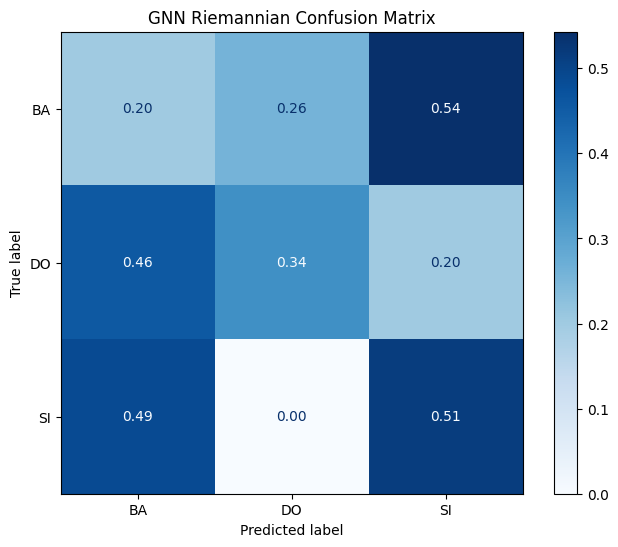

In [25]:


# 3. Test the model
y_true, y_pred = evaluate_riemannian_gnn(model, test_loader, device)

In [28]:
model, test_loader = train_riemannian_gnn(total_data, test_data, "S1_")

--- Training Subject: S1_ on cpu ---
Epoch 010 | Train Loss: 0.9229 | Val Loss: 0.9266 | Val Acc: 0.53
Epoch 020 | Train Loss: 0.8103 | Val Loss: 0.8333 | Val Acc: 0.60
Epoch 030 | Train Loss: 0.7528 | Val Loss: 0.7620 | Val Acc: 0.64
Epoch 040 | Train Loss: 0.5838 | Val Loss: 0.7247 | Val Acc: 0.67
Epoch 050 | Train Loss: 0.4669 | Val Loss: 0.8979 | Val Acc: 0.68
Epoch 060 | Train Loss: 0.3738 | Val Loss: 0.6976 | Val Acc: 0.75
Epoch 070 | Train Loss: 0.3044 | Val Loss: 0.5800 | Val Acc: 0.77
Epoch 080 | Train Loss: 0.3124 | Val Loss: 0.7657 | Val Acc: 0.76
Epoch 090 | Train Loss: 0.3265 | Val Loss: 0.8247 | Val Acc: 0.77
Epoch 100 | Train Loss: 0.1558 | Val Loss: 0.6610 | Val Acc: 0.80
Epoch 110 | Train Loss: 0.2182 | Val Loss: 0.6352 | Val Acc: 0.82
Epoch 120 | Train Loss: 0.1414 | Val Loss: 0.5893 | Val Acc: 0.86
Epoch 130 | Train Loss: 0.1226 | Val Loss: 0.7854 | Val Acc: 0.84
Epoch 140 | Train Loss: 0.1144 | Val Loss: 0.7562 | Val Acc: 0.86
Epoch 150 | Train Loss: 0.0869 | Val Lo

🧐 Evaluating on test set...

✅ Evaluation Complete.
              precision    recall  f1-score   support

          BA       0.19      0.17      0.18        35
          DO       0.34      0.37      0.36        35
          SI       0.36      0.37      0.37        35

    accuracy                           0.30       105
   macro avg       0.30      0.30      0.30       105
weighted avg       0.30      0.30      0.30       105



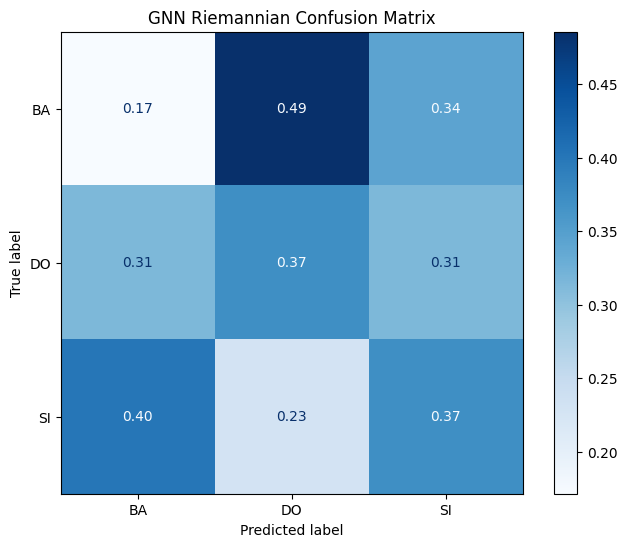

In [29]:
y_true, y_pred = evaluate_riemannian_gnn(model, test_loader, device)

## model performance with confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

In [ ]:
def model_performance(train_dict, test_dict, clf_type, class_names=['BA', 'DO', 'SI']):
    total_acc_results = {}
    
    # We iterate over subjects in the training dictionary
    for subject in train_dict.keys():
        # Safety check: make sure this subject actually has a test block
        if subject not in test_dict or 'data' not in test_dict[subject]:
            print(f"Skipping {subject}: No test data found.")
            continue

        print(f"--- Evaluating {subject} ---")
        
        # 1. Prepare Training Data (all blocks except the 3rd)
        X_train = train_dict[subject]['data']
        y_train = train_dict[subject]['labels']
        
        # 2. Prepare Test Data (the 3rd block we kept separate)
        X_test = test_dict[subject]['data']
        y_test = test_dict[subject]['labels']
        
        print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

        # 3. Predict 
        # We don't need the loop for K-Fold anymore because we have a fixed test set
        y_pred = riemannian_model_build(X_train, y_train, X_test, clf_type)
        
        # 4. Calculate Accuracy
        acc = accuracy_score(y_test, y_pred)
        total_acc_results[subject] = acc
        print(f"Final Test Accuracy: {acc:.4f}")

        # 5. Plot Confusion Matrix for this specific test block
        cm = confusion_matrix(y_test, y_pred, normalize='true')
        
        fig, ax = plt.subplots(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(cmap='Blues', ax=ax, values_format='.2g')
        plt.title(f"Hold-out Test: {subject} ({clf_type})")
        
        # Save and Show
        #save_path = f"/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/confusion_matrices/holdout_{clf_type}_{subject}.png"
        #plt.savefig(save_path)
        plt.show()
    
    return total_acc_results

In [ ]:
MLP_acc_dict = model_performance(total_data, test_data,clf_type='mlp')


In [ ]:
xgb_acc_dict = model_performance(total_data, test_data,clf_type='xgboost')


In [ ]:

logreg_acc_dict = model_performance(total_data,test_data, clf_type='logreg')

In [ ]:
import json

# Save the dictionary to a file
with open('logreg_acc_results_0.4_chunk.json', 'w') as f:
    json.dump(logreg_acc_dict, f, indent=4)

print("Results saved to logreg_acc_results.json")

# To load it back later:
# with open('logreg_acc_results.json', 'r') as f:
#     loaded_results = json.load(f)

In [ ]:
svm_acc_dict = model_performance(total_data, test_data,clf_type='svm')

In [ ]:
import json

In [ ]:

with open('svm_acc_results_0.5_chunk.json', 'w') as f:
    json.dump(svm_acc_dict, f, indent=4)

In [ ]:
subject_labels = list(logreg_acc_dict.keys())

plt.figure(figsize=(25, 8))
bars = plt.bar(subject_labels, [np.mean(logreg_acc_dict[subj]) for subj in subject_labels], color='skyblue')
plt.xlabel('Test Subject (Fold)')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy for Each Subject (within subjects): Logistic Regression')
plt.bar_label(bars, padding=2)
plt.show()

In [ ]:
subject_labels = list(logreg_acc_dict.keys())

for fold_num in range(5):
     fold_accuracies = [logreg_acc_dict[subj][fold_num] for subj in subject_labels]
     plt.figure(figsize=(15, 5))
     bars = plt.bar(subject_labels, fold_accuracies, color='skyblue')
     plt.xlabel('Test Subject (Fold)')
     plt.xticks(rotation=45, ha='right')
     plt.ylabel('Test Accuracy')
     plt.title(f'Test Accuracy for Each Subject (within subjects): Logistic Regression - Fold {fold_num + 1}')
     plt.bar_label(bars, padding=2)
     plt.ylim(0, max(fold_accuracies) + 0.05)  # Set y-axis limits to [0, 1] for better visualization
     plt.show()

In [ ]:
subject_labels = list(svm_acc_dict.keys())

plt.figure(figsize=(25, 8))
bars = plt.bar(subject_labels, [np.mean(svm_acc_dict[subj]) for subj in subject_labels], color='skyblue')
plt.xlabel('Test Subject (Fold)')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy for Each Subject (within subjects): SVM')
plt.bar_label(bars, padding=2)
plt.show()

In [ ]:
subject_labels = list(svm_acc_dict.keys())

for fold_num in range(5):
     fold_accuracies = [svm_acc_dict[subj][fold_num] for subj in subject_labels]
     plt.figure(figsize=(15, 5))
     bars = plt.bar(subject_labels, fold_accuracies, color='skyblue')
     plt.xlabel('Test Subject (Fold)')
     plt.xticks(rotation=45, ha='right')
     plt.ylabel('Test Accuracy')
     plt.title(f'Test Accuracy for Each Subject (within subjects): SVM - Fold {fold_num + 1}')
     plt.bar_label(bars, padding=2)
     plt.ylim(0, max(fold_accuracies) + 0.05)  # Set y-axis limits to [0, 1] for better visualization
     plt.show()

In [ ]:
all_subjects = list(total_data.keys())


for test_sub in all_subjects:
    print(f"\n-- Runnning LOSO: Testing on {test_sub}")

    test_data = {test_sub: total_data[test_sub]}

    train_data = {s: total_data[s] for s in all_subjects if s != test_sub}

    results = loso_model_performance(train_data, test_data, clf_type= "logreg")